# LINEAR REGRESSION 

In [1]:
## LIBS IMPORTING 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics 






In [2]:
sns.set_theme(style="whitegrid")

In [5]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)



In [4]:

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")
display(df.head()) 

Dataset Shape: 1338 rows and 7 columns



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Checking for Missing Values ---")
print(df.isnull().sum())


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Summary Statistics ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



--- Checking for Missing Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

print("\n--- Data After Encoding Categorical Variables ---")
display(df_encoded.head())


--- Data After Encoding Categorical Variables ---


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


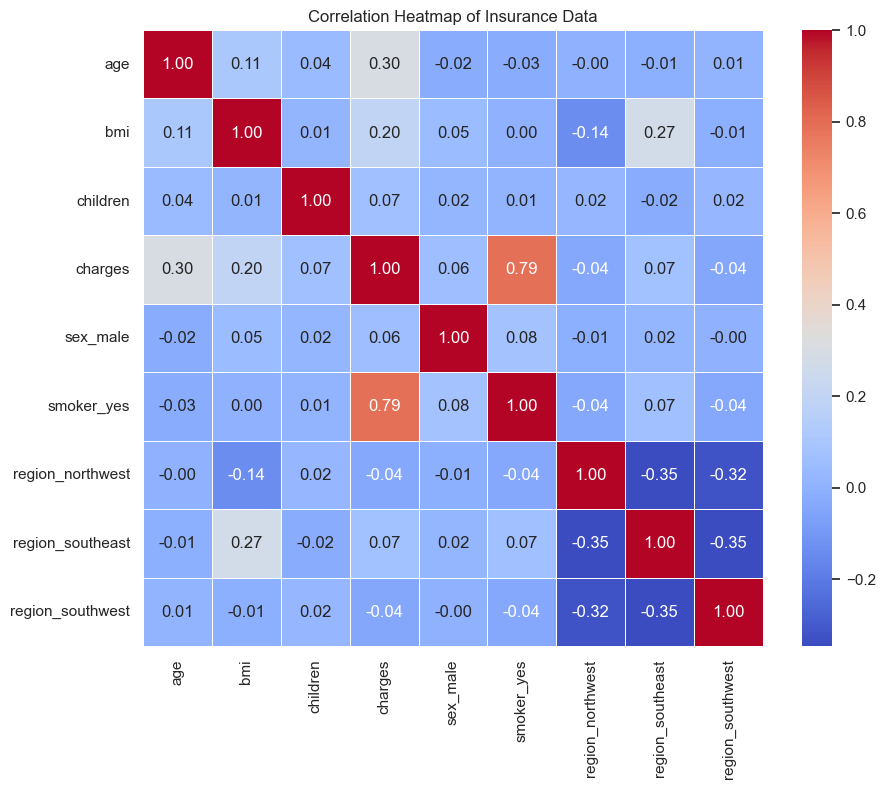

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Insurance Data')
plt.show()

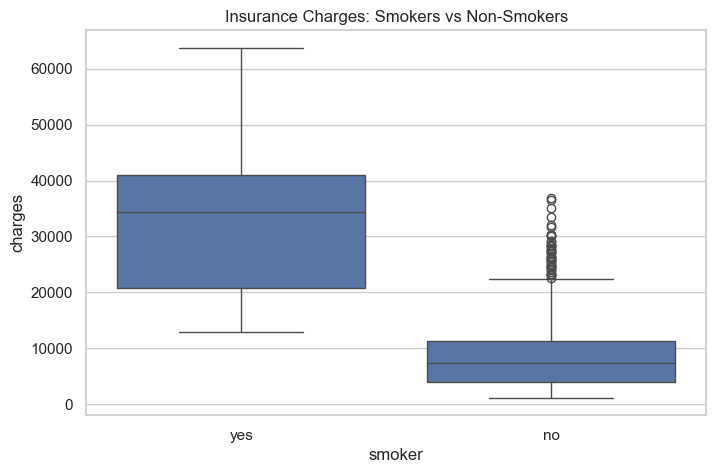

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges: Smokers vs Non-Smokers')
plt.show()

In [11]:

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [12]:
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

print("\n--- Model Evaluation ---")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")


--- Model Evaluation ---
R-squared (R2): 0.7836
Mean Absolute Error (MAE): $4181.19
Root Mean Squared Error (RMSE): $5796.28


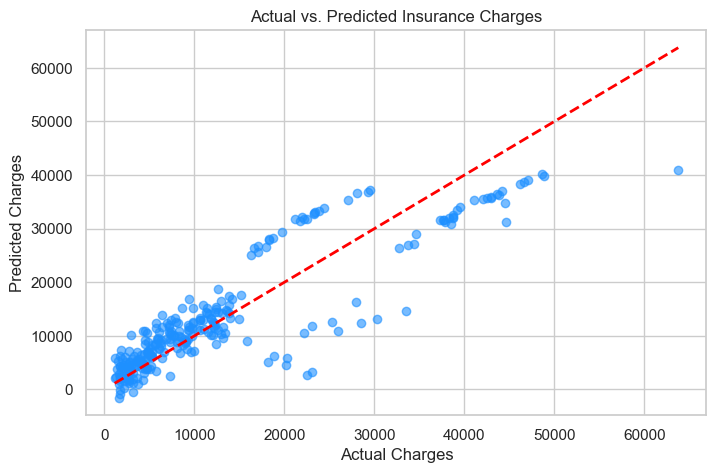

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Insurance Charges')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.show()

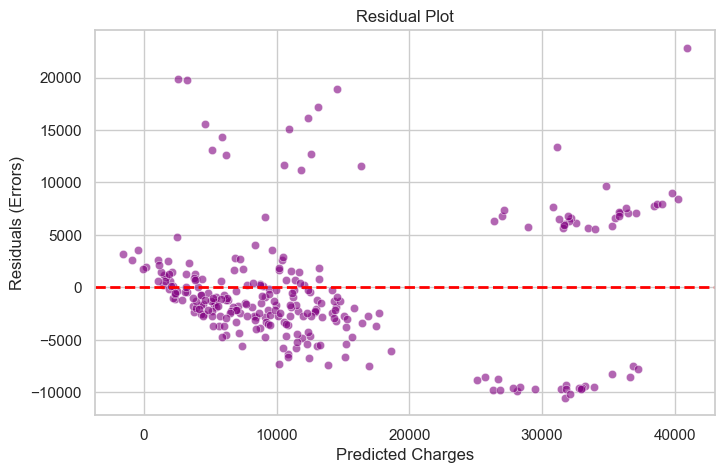

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Errors)')
plt.show()

In [15]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"--- Model 'Accuracy' Metrics ---")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"This means our predictions are off by an average of {mape:.2f}% from the actual cost.\n")

--- Model 'Accuracy' Metrics ---
Mean Absolute Percentage Error (MAPE): 46.89%
This means our predictions are off by an average of 46.89% from the actual cost.



In [ ]:
new_queries = pd.DataFrame({
    'age': [19, 50, 30],               
    'bmi': [27.9, 34.0, 22.5],         
    'children': [0, 2, 1],             
    'sex_male': [0, 1, 0],             
    'smoker_yes': [0, 1, 0],           
    'region_northwest': [0, 0, 1],     
    'region_southeast': [0, 1, 0],
    'region_southwest': [1, 0, 0]
})

new_predictions = model.predict(new_queries)

print("\n--- Predictions for Custom Queries ---")
for i, pred in enumerate(new_predictions):
    smoker_status = "Smoker" if new_queries.loc[i, 'smoker_yes'] == 1 else "Non-Smoker"
    print(f"Person {i+1} ({new_queries.loc[i, 'age']} yrs, BMI {new_queries.loc[i, 'bmi']}, {smoker_status}):")
    print(f"   -> Predicted Insurance Cost: ${pred:.2f}\n")


--- Predictions for Custom Queries ---
Person 1 (19 yrs, BMI 27.9, Non-Smoker):
   -> Predicted Insurance Cost: $1546.40

Person 2 (50 yrs, BMI 34.0, Smoker):
   -> Predicted Insurance Cost: $36203.94

Person 3 (30 yrs, BMI 22.5, Non-Smoker):
   -> Predicted Insurance Cost: $3417.24

